In [1]:
# ============================================================
# INSTALL ADDITIONAL LIBRARIES (ONLY IF USING KAGGLE/COLAB)
# ============================================================

# MODIFICATION:
# We install Albumentations to ensure synchronized image-mask augmentation.
# This fixes the issue where image and mask transformations were not aligned.

!pip install albumentations --quiet


In [2]:
# ============================================================
# LIBRARY IMPORTS
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

# Evaluation Metrics
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score, confusion_matrix
import seaborn as sns

# MODIFICATION: Albumentations for synchronized augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Device configuration (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [3]:
# ============================================================
# U-NET ARCHITECTURE (BASELINE MODEL)
# ============================================================

# NOTE:
# Architecture is kept SAME as baseline.
# We are only improving the training pipeline, not architecture.

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super().__init__()

        def double_conv(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            )

        # Encoder
        self.dconv_down1 = double_conv(n_channels, 64)
        self.dconv_down2 = double_conv(64, 128)
        self.dconv_down3 = double_conv(128, 256)
        self.dconv_down4 = double_conv(256, 512)

        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # Decoder
        self.dconv_up3 = double_conv(256 + 512, 256)
        self.dconv_up2 = double_conv(128 + 256, 128)
        self.dconv_up1 = double_conv(64 + 128, 64)

        self.conv_last = nn.Conv2d(64, n_classes, 1)

    def forward(self, x):
        c1 = self.dconv_down1(x)
        x = self.maxpool(c1)

        c2 = self.dconv_down2(x)
        x = self.maxpool(c2)

        c3 = self.dconv_down3(x)
        x = self.maxpool(c3)

        x = self.dconv_down4(x)

        x = self.upsample(x)
        x = torch.cat([x, c3], dim=1)
        x = self.dconv_up3(x)

        x = self.upsample(x)
        x = torch.cat([x, c2], dim=1)
        x = self.dconv_up2(x)

        x = self.upsample(x)
        x = torch.cat([x, c1], dim=1)
        x = self.dconv_up1(x)

        return self.conv_last(x)


In [4]:
# ============================================================
# DATA AUGMENTATION (SYNCHRONIZED IMAGE & MASK)
# ============================================================

# MODIFICATION:
# Albumentations ensures SAME random transform applied to image and mask.

train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.Normalize(),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(),
    ToTensorV2()
])


In [5]:
# ============================================================
# CUSTOM DATASET CLASS
# ============================================================

class PolypDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])

        image = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path).convert("L"))

        # MODIFICATION:
        # Apply SAME transformation to image and mask
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        mask = mask.unsqueeze(0).float()
        mask = (mask > 0).float()

        return image, mask


In [6]:
# ============================================================
# DATASET INITIALIZATION
# ============================================================

image_dir = "/kaggle/input/colorectal-polyp-segmentation-dataset/polyp_dataset/images"
mask_dir  = "/kaggle/input/colorectal-polyp-segmentation-dataset/polyp_dataset/masks"

full_dataset = PolypDataset(image_dir, mask_dir, transform=train_transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

# Apply validation transform properly
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)


In [7]:
# ============================================================
# LOSS FUNCTION (Dice + BCE)
# ============================================================

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)
        preds = preds.view(-1)
        targets = targets.view(-1)

        intersection = (preds * targets).sum()
        dice = (2 * intersection + self.smooth) / (preds.sum() + targets.sum() + self.smooth)

        return 1 - dice


class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.dice = DiceLoss()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, preds, targets):
        # MODIFICATION:
        # Increase Dice weight to emphasize overlap learning
        return 0.8 * self.dice(preds, targets) + 0.2 * self.bce(preds, targets)


In [9]:
# ============================================================
# MODEL INITIALIZATION & OPTIMIZATION
# ============================================================

model = UNet().to(device)

# MODIFICATION:
# Added weight decay for regularization
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

# MODIFICATION:
# Learning Rate Scheduler to improve convergence
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)


criterion = DiceBCELoss()


In [10]:
# ============================================================
# TRAINING & VALIDATION LOOP (WITH ACCURACY + SCHEDULER)
# ============================================================

num_epochs = 25

train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_loss = float('inf')

for epoch in range(num_epochs):

    # -------------------- TRAINING --------------------
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

        # Accuracy calculation (threshold = 0.5)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == masks).sum().item()
        total += masks.numel()

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = (correct / total) * 100

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # -------------------- VALIDATION --------------------
    model.eval()
    val_running_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, masks)

            val_running_loss += loss.item() * imgs.size(0)

            preds = (torch.sigmoid(outputs) > 0.5).float()
            val_correct += (preds == masks).sum().item()
            val_total += masks.numel()

    val_loss = val_running_loss / len(val_loader.dataset)
    val_acc = (val_correct / val_total) * 100

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Scheduler step
    scheduler.step(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "unet_improved.pth")
        best_msg = " (BEST MODEL SAVED)"
    else:
        best_msg = ""

    # -------------------- Epoch Summary --------------------
    print(f"Epoch [{epoch+1}/{num_epochs}] COMPLETED{best_msg}")
    print(f" Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f" Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")
    print("-" * 55)


Epoch [1/25] COMPLETED (BEST MODEL SAVED)
 Train Loss: 0.6217 | Train Acc: 72.58%
 Val   Loss: 0.5862 | Val   Acc: 83.25%
-------------------------------------------------------
Epoch [2/25] COMPLETED (BEST MODEL SAVED)
 Train Loss: 0.5582 | Train Acc: 80.18%
 Val   Loss: 0.5299 | Val   Acc: 87.02%
-------------------------------------------------------
Epoch [3/25] COMPLETED (BEST MODEL SAVED)
 Train Loss: 0.5191 | Train Acc: 83.14%
 Val   Loss: 0.5044 | Val   Acc: 83.65%
-------------------------------------------------------
Epoch [4/25] COMPLETED (BEST MODEL SAVED)
 Train Loss: 0.4947 | Train Acc: 84.40%
 Val   Loss: 0.4739 | Val   Acc: 85.25%
-------------------------------------------------------
Epoch [5/25] COMPLETED
 Train Loss: 0.4713 | Train Acc: 85.49%
 Val   Loss: 0.5126 | Val   Acc: 80.40%
-------------------------------------------------------
Epoch [6/25] COMPLETED (BEST MODEL SAVED)
 Train Loss: 0.4421 | Train Acc: 87.09%
 Val   Loss: 0.4019 | Val   Acc: 90.04%
-------

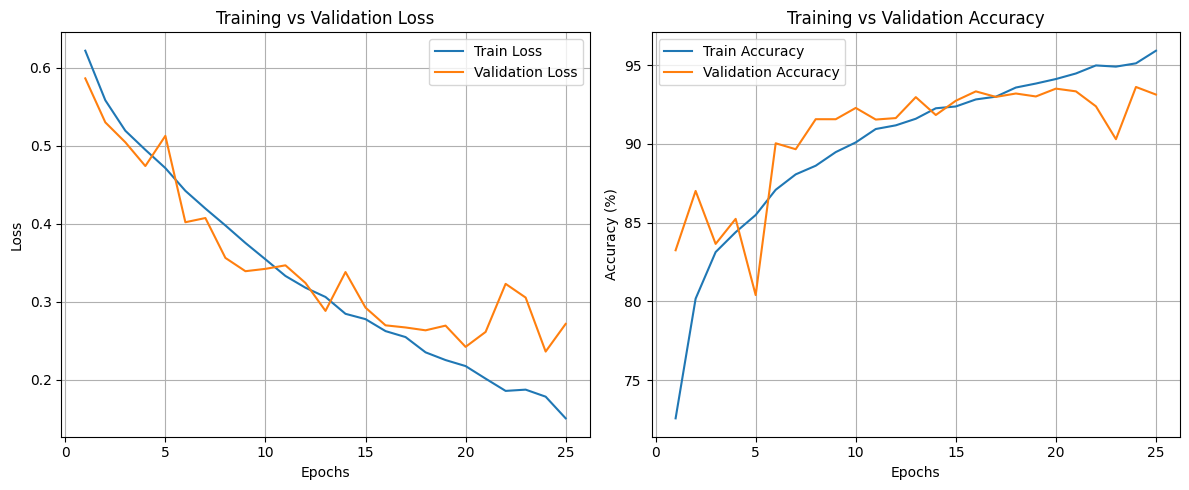

In [11]:
# ============================================================
# TRAINING & VALIDATION PERFORMANCE CURVES
# ============================================================

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Loss curves
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

# Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, val_accs, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [12]:
# ============================================================
# LOAD BEST TRAINED MODEL
# ============================================================

# Purpose:
# Load the best model (lowest validation loss) before evaluation.

model = UNet().to(device)
model.load_state_dict(torch.load("unet_improved.pth", map_location=device))
model.eval()

print("Best improved model loaded successfully.")


Best improved model loaded successfully.


In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score, accuracy_score

def calculate_metrics(model, loader):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)

            # Threshold = 0.5
            preds = (torch.sigmoid(outputs) > 0.5).float()

            all_preds.append(preds.cpu().view(-1))
            all_targets.append(masks.cpu().view(-1))

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    precision = precision_score(all_targets, all_preds, zero_division=0)
    recall = recall_score(all_targets, all_preds, zero_division=0)
    f1 = f1_score(all_targets, all_preds, zero_division=0)
    iou = jaccard_score(all_targets, all_preds, zero_division=0)
    accuracy = accuracy_score(all_targets, all_preds)   # ✅ ADDED

    return precision, recall, f1, iou, accuracy


precision, recall, f1, iou, accuracy = calculate_metrics(model, val_loader)

print("\n=== Improved U-Net Metrics ===")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"IoU       : {iou:.4f}")
print(f"Accuracy  : {accuracy:.4f}")



=== Improved U-Net Metrics ===
Precision : 0.8177
Recall    : 0.7429
F1-Score  : 0.7785
IoU       : 0.6373
Accuracy  : 0.9362


In [15]:
# ============================================================
# LOAD BEST TRAINED MODEL
# ============================================================

# Purpose:
# Load the best model (lowest validation loss) before evaluation.

model = UNet().to(device)
model.load_state_dict(torch.load("unet_improved.pth", map_location=device))
model.eval()

print("Best improved model loaded successfully.")


Best improved model loaded successfully.


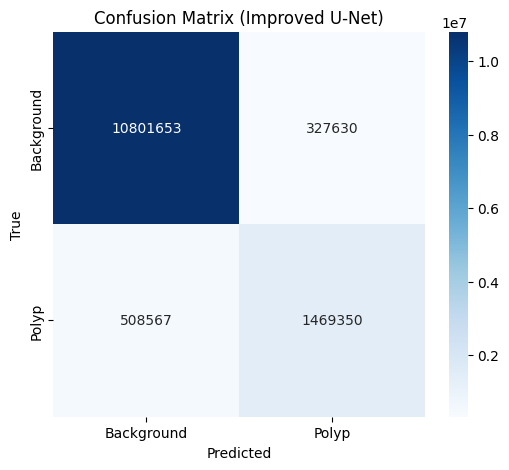

In [17]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

def plot_confusion_matrix(model, loader):
    model.eval()
    preds_all = []
    targets_all = []

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)

            preds = (torch.sigmoid(outputs) > 0.5).float()

            preds_all.append(preds.cpu().view(-1))
            targets_all.append(masks.cpu().view(-1))

    preds_all = torch.cat(preds_all).numpy()
    targets_all = torch.cat(targets_all).numpy()

    cm = confusion_matrix(targets_all, preds_all)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Background', 'Polyp'],
        yticklabels=['Background', 'Polyp']
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix (Improved U-Net)")
    plt.show()


plot_confusion_matrix(model, val_loader)


In [18]:
# ============================================================
# PER-SAMPLE IoU ANALYSIS
# ============================================================

def calculate_iou_per_sample(model, loader):
    model.eval()
    ious = []

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)

            preds = (torch.sigmoid(outputs) > 0.5).float()

            for i in range(preds.size(0)):
                intersection = (preds[i] * masks[i]).sum()
                union = (preds[i] + masks[i]).sum() - intersection
                iou = (intersection / (union + 1e-6)).item()
                ious.append(iou)

    return ious


val_ious = calculate_iou_per_sample(model, val_loader)

print("\nIoU Statistics (Improved U-Net)")
print(f"Mean IoU: {np.mean(val_ious):.4f}")
print(f"Std  IoU: {np.std(val_ious):.4f}")
print(f"Min  IoU: {np.min(val_ious):.4f}")
print(f"Max  IoU: {np.max(val_ious):.4f}")



IoU Statistics (Improved U-Net)
Mean IoU: 0.6470
Std  IoU: 0.2141
Min  IoU: 0.0000
Max  IoU: 0.9613


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5877123].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5877123].


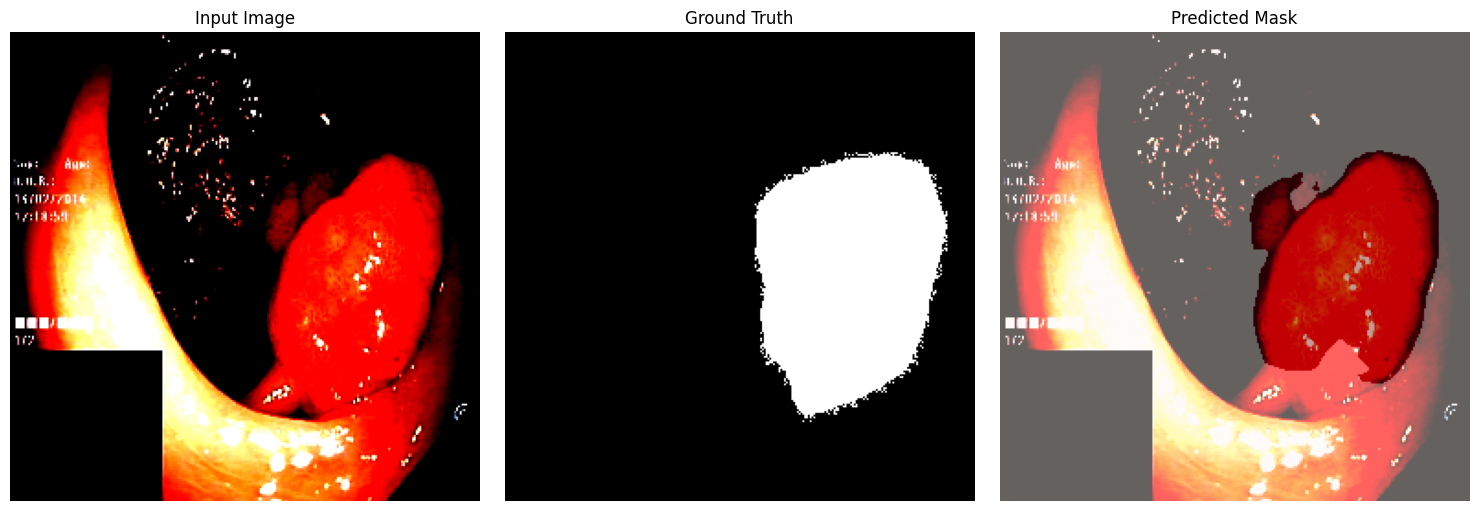

In [19]:
# ============================================================
# VISUALIZATION OF SEGMENTATION RESULTS
# ============================================================

model.eval()

with torch.no_grad():
    imgs, masks = next(iter(val_loader))
    imgs, masks = imgs.to(device), masks.to(device)

    outputs = model(imgs)
    preds = (torch.sigmoid(outputs) > 0.5).float()

    num_images = 1
    fig, axes = plt.subplots(num_images, 3, figsize=(15, 5))

    axes[0].imshow(imgs[0].cpu().permute(1, 2, 0))
    axes[0].set_title("Input Image")
    axes[0].axis("off")

    axes[1].imshow(masks[0].cpu().squeeze(), cmap="gray")
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    axes[2].imshow(imgs[0].cpu().permute(1, 2, 0))
    axes[2].imshow(preds[0].cpu().squeeze(), cmap="Reds", alpha=0.4)
    axes[2].set_title("Predicted Mask")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()
